In [1]:
# ======================================================================
# TP ACP NORMEE - BOISSONS DE JUS
# Objectif :
#   - Réaliser une ACP normée (matrice de corrélation)
#   - Représenter graphiquement individus & variables
#   - Calculer cos², contributions
#   - Comparer les boissons sur toutes les caractéristiques
#   - INTERPRETER : caractériser les boissons et trouver des groupes
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

plt.rcParams["figure.dpi"] = 130

# ----------------------------------------------------------------------
# 1) Données (10 boissons x 10 caractéristiques)
# ----------------------------------------------------------------------
boissons = [
    "Boisson 1","Boisson 2","Boisson 3","Boisson 4","Boisson 5",
    "Boisson 6","Boisson 7","Boisson 8","Boisson 9","Boisson 10"
]

variables = ["Frut","Suc","Gt","Amr","Piq","Rug","Odr","Acd","Parf","Suff"]

X = np.array([
    [2.29, 2.86, 2.86, 3.29, 3.29, 3.00, 3.14, 4.29, 2.29, 0.54],  # B1
    [1.14, 1.79, 3.86, 3.57, 3.57, 3.00, 3.43, 3.71, 1.43, 0.93],  # B2
    [2.71, 4.14, 1.86, 3.57, 3.14, 2.43, 3.71, 3.57, 3.29, 0.64],  # B3
    [4.14, 4.71, 2.00, 3.07, 2.29, 2.57, 4.00, 3.14, 4.14, 0.00],  # B4
    [1.29, 2.29, 3.86, 4.14, 2.86, 3.17, 4.43, 3.86, 2.14, 1.50],  # B5
    [0.00, 1.86, 4.29, 4.79, 2.71, 3.57, 4.14, 3.86, 1.14, 0.64],  # B6
    [3.86, 4.71, 1.57, 2.57, 2.00, 2.71, 3.43, 4.21, 3.57, 0.50],  # B7
    [0.00, 0.00, 2.86, 3.86, 2.71, 3.00, 4.14, 3.86, 1.14, 0.93],  # B8
    [4.07, 4.14, 2.29, 4.00, 1.43, 3.00, 4.07, 3.57, 3.57, 0.50],  # B9
    [3.71, 3.86, 2.43, 4.07, 1.43, 2.79, 6.10, 3.86, 1.57, 2.21],  # B10
])

df = pd.DataFrame(X, index=boissons, columns=variables)
df.index.name = "Boisson"

print("\n(1) MATRICE DES DONNEES :\n")
print(df.round(2))


(1) MATRICE DES DONNEES :

            Frut   Suc    Gt   Amr   Piq   Rug   Odr   Acd  Parf  Suff
Boisson                                                               
Boisson 1   2.29  2.86  2.86  3.29  3.29  3.00  3.14  4.29  2.29  0.54
Boisson 2   1.14  1.79  3.86  3.57  3.57  3.00  3.43  3.71  1.43  0.93
Boisson 3   2.71  4.14  1.86  3.57  3.14  2.43  3.71  3.57  3.29  0.64
Boisson 4   4.14  4.71  2.00  3.07  2.29  2.57  4.00  3.14  4.14  0.00
Boisson 5   1.29  2.29  3.86  4.14  2.86  3.17  4.43  3.86  2.14  1.50
Boisson 6   0.00  1.86  4.29  4.79  2.71  3.57  4.14  3.86  1.14  0.64
Boisson 7   3.86  4.71  1.57  2.57  2.00  2.71  3.43  4.21  3.57  0.50
Boisson 8   0.00  0.00  2.86  3.86  2.71  3.00  4.14  3.86  1.14  0.93
Boisson 9   4.07  4.14  2.29  4.00  1.43  3.00  4.07  3.57  3.57  0.50
Boisson 10  3.71  3.86  2.43  4.07  1.43  2.79  6.10  3.86  1.57  2.21


In [2]:

# ----------------------------------------------------------------------
# 2) ACP NORMEE (matrice de CORRELATION)
# ----------------------------------------------------------------------
n, p = df.shape

moy = df.mean(axis=0)
std = df.std(axis=0, ddof=0)  # var avec 1/n
Z = (df - moy) / std          # données centrées-réduites

print("\n(2) MOYENNES :\n")
print(moy.round(3))
print("\n(3) ECARTS-TYPES :\n")
print(std.round(3))

R = (Z.T @ Z) / n
R_df = pd.DataFrame(R, index=variables, columns=variables)

print("\n(4) MATRICE DE CORRELATION R :\n")
print(R_df.round(3))

# valeurs propres / vecteurs propres (sur R)
valp, vecp = np.linalg.eigh(R)
idx = np.argsort(valp)[::-1]
valp = valp[idx]
vecp = vecp[:, idx]

axes = [f"F{i+1}" for i in range(p)]
inertie_tot = valp.sum()
taux = valp / inertie_tot * 100
taux_cum = taux.cumsum()

axes_df = pd.DataFrame({
    "Axe": axes,
    "Valeur_propre": valp,
    "Taux_inertie_%": taux,
    "Taux_cumule_%": taux_cum
})

print("\n(5) VALEURS PROPRES / TAUX D'INERTIE :\n")
print(axes_df.round(3))
print(f"\n=> F1 + F2 expliquent {taux_cum[1]:.2f}% de l'information totale.\n")


(2) MOYENNES :

Frut    2.321
Suc     3.036
Gt      2.788
Amr     3.693
Piq     2.543
Rug     2.924
Odr     4.059
Acd     3.793
Parf    2.428
Suff    0.839
dtype: float64

(3) ECARTS-TYPES :

Frut    1.551
Suc     1.465
Gt      0.889
Amr     0.592
Piq     0.704
Rug     0.306
Odr     0.780
Acd     0.312
Parf    1.069
Suff    0.586
dtype: float64

(4) MATRICE DE CORRELATION R :

       Frut    Suc     Gt    Amr    Piq    Rug    Odr    Acd   Parf   Suff
Frut  1.000  0.931 -0.802 -0.554 -0.631 -0.684  0.137 -0.254  0.812 -0.148
Suc   0.931  1.000 -0.719 -0.497 -0.501 -0.626  0.042 -0.252  0.842 -0.237
Gt   -0.802 -0.719  1.000  0.695  0.482  0.859  0.027  0.153 -0.759  0.274
Amr  -0.554 -0.497  0.695  1.000 -0.034  0.710  0.493 -0.083 -0.632  0.444
Piq  -0.631 -0.501  0.482 -0.034  1.000  0.143 -0.605  0.141 -0.332 -0.196
Rug  -0.684 -0.626  0.859  0.710  0.143  1.000  0.037  0.339 -0.661  0.158
Odr   0.137  0.042  0.027  0.493 -0.605  0.037  1.000 -0.157 -0.290  0.784
Acd  -0.254 -0.252 

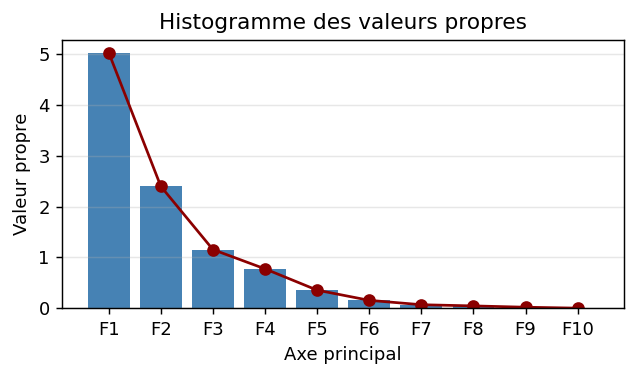

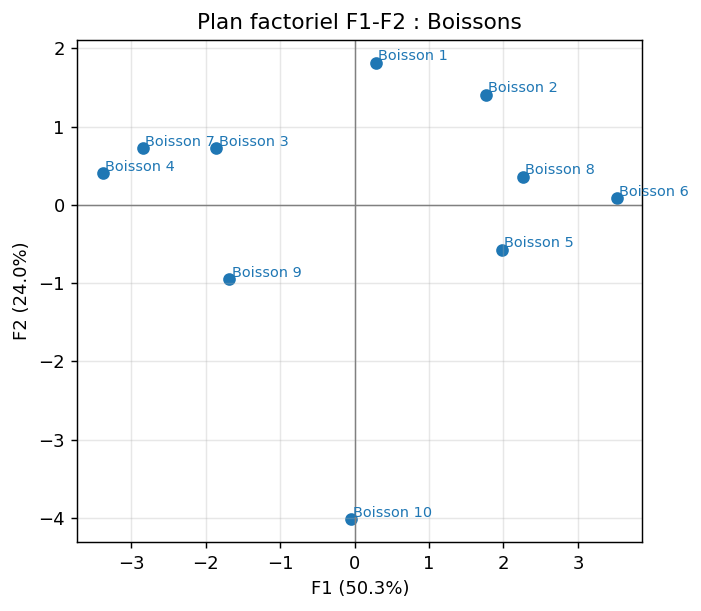

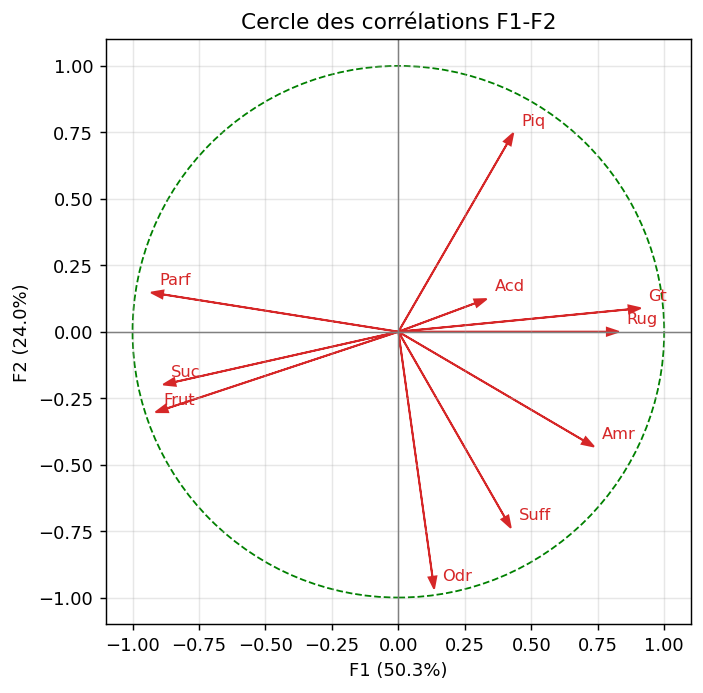

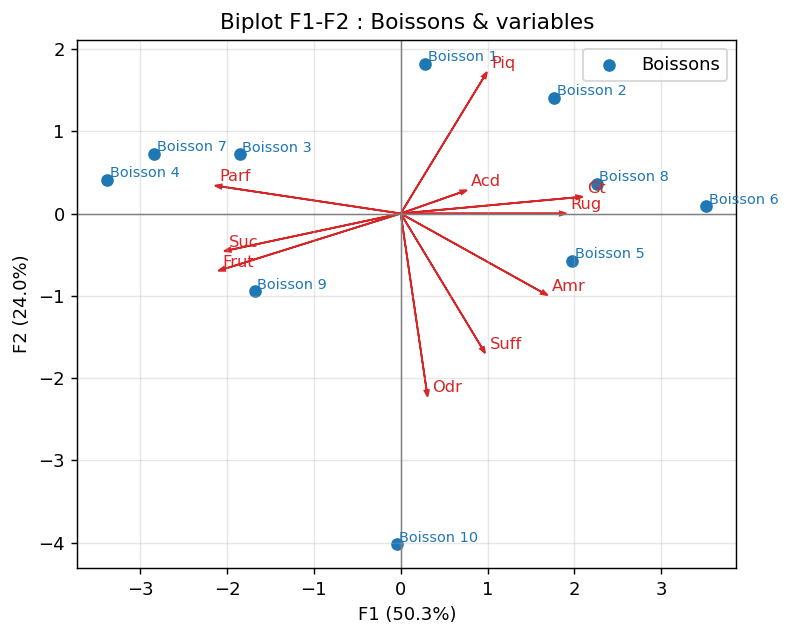

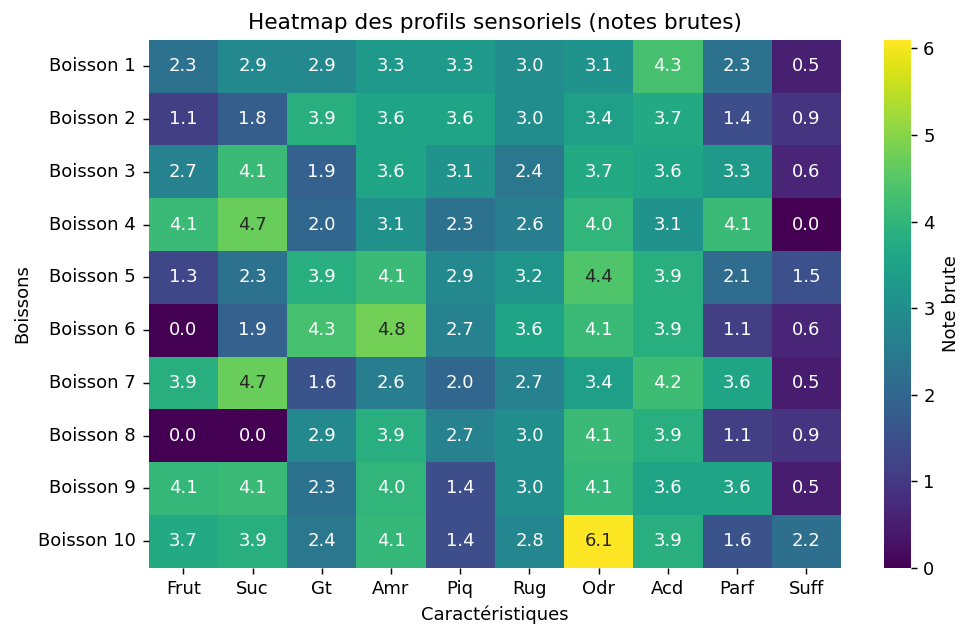

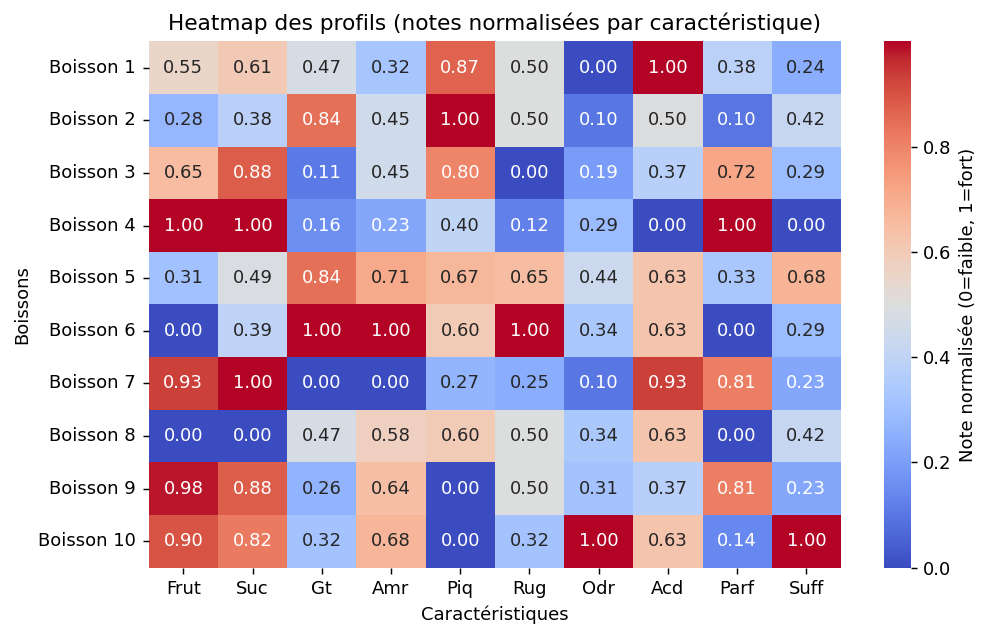


================ INTERPRETATION DES AXES ==================

Axe F1 :
  - Variables les plus contributives :
    * Parf (ctr ≈ 17.19%)
    * Frut (ctr ≈ 16.57%)
    * Gt (ctr ≈ 16.50%)
    * Suc (ctr ≈ 15.53%)
    * Rug (ctr ≈ 13.65%)
  - F1 est un axe de 'profil global agréable' :
    il oppose les boissons fruitées/sucrées/parfumées (Frut, Suc, Parf, Odr)
    aux boissons à goût plus lourd / amer (Amr, Gt).

Axe F2 :
  - Variables les plus contributives :
    * Odr (ctr ≈ 38.94%)
    * Piq (ctr ≈ 23.28%)
    * Suff (ctr ≈ 22.67%)
    * Amr (ctr ≈ 7.78%)
    * Frut (ctr ≈ 3.82%)
  - F2 exprime un contraste entre piquant/rugueux (Piq, Rug, Odr)
    et caractère suffocant (Suff).

================ GROUPES DE BOISSONS (PLAN F1-F2) =========

(1) Boissons avec F1 très POSITIF (profil agréable : fruité/sucré/parfumé):
Boisson 6    3.519
Boisson 8    2.256
Boisson 5    1.977
Boisson 2    1.768
Name: F1, dtype: float64

(2) Boissons avec F1 très NEGATIF (profil moins agréable / plus amer):


In [3]:


# ----------------------------------------------------------------------
# 3) Coordonnées des individus et variables
# ----------------------------------------------------------------------
C = Z.values @ vecp  # coord individus
coord_ind_df = pd.DataFrame(C, index=boissons, columns=axes)

phi = vecp * np.sqrt(np.clip(valp, 0, None))  # coord variables
coord_var_df = pd.DataFrame(phi, index=variables, columns=axes)

# cos² individus sur F1-F2
dist2_ind = (coord_ind_df**2).sum(axis=1)
cos2_ind_F12 = ((coord_ind_df["F1"]**2 + coord_ind_df["F2"]**2) / dist2_ind) * 100

# cos² variables sur F1-F2
cos2_var_df = coord_var_df**2

# contributions
contrib_ind_F1 = (coord_ind_df["F1"]**2 / (n * valp[0])) * 100
contrib_ind_F2 = (coord_ind_df["F2"]**2 / (n * valp[1])) * 100
contrib_var_F1 = (coord_var_df["F1"]**2 / valp[0]) * 100
contrib_var_F2 = (coord_var_df["F2"]**2 / valp[1]) * 100

# ----------------------------------------------------------------------
# 4) Graphiques ACP "propres"
# ----------------------------------------------------------------------

# 4.1 Histogramme VP
plt.figure(figsize=(5,3))
plt.bar(range(1, p+1), valp, color="steelblue")
plt.plot(range(1, p+1), valp, marker="o", color="darkred")
plt.xticks(range(1, p+1), axes)
plt.xlabel("Axe principal")
plt.ylabel("Valeur propre")
plt.title("Histogramme des valeurs propres")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2 Plan factoriel F1-F2 (individus)
plt.figure(figsize=(5.5,4.8))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.scatter(coord_ind_df["F1"], coord_ind_df["F2"], color="tab:blue")

for b in boissons:
    x = coord_ind_df.loc[b, "F1"]
    y = coord_ind_df.loc[b, "F2"]
    plt.text(x + 0.03, y + 0.03, b, fontsize=8, color="tab:blue")

plt.xlabel(f"F1 ({taux[0]:.1f}%)")
plt.ylabel(f"F2 ({taux[1]:.1f}%)")
plt.title("Plan factoriel F1-F2 : Boissons")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.3 Cercle des corrélations
plt.figure(figsize=(5.5,5.5))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

circle = plt.Circle((0,0), 1, color="green", fill=False, linestyle="--")
plt.gca().add_artist(circle)

for v in variables:
    x = coord_var_df.loc[v, "F1"]
    y = coord_var_df.loc[v, "F2"]
    plt.arrow(0, 0, x, y, color="tab:red", head_width=0.03, length_includes_head=True)
    plt.text(x + 0.03, y + 0.03, v, fontsize=9, color="tab:red")

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel(f"F1 ({taux[0]:.1f}%)")
plt.ylabel(f"F2 ({taux[1]:.1f}%)")
plt.title("Cercle des corrélations F1-F2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.4 Biplot F1-F2 (individus + variables)
plt.figure(figsize=(6.2,5))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

plt.scatter(coord_ind_df["F1"], coord_ind_df["F2"], color="tab:blue", label="Boissons")
for b in boissons:
    plt.text(coord_ind_df.loc[b, "F1"] + 0.03,
             coord_ind_df.loc[b, "F2"] + 0.03,
             b, fontsize=8, color="tab:blue")

scale = 2.3
for v in variables:
    x = coord_var_df.loc[v, "F1"] * scale
    y = coord_var_df.loc[v, "F2"] * scale
    plt.arrow(0, 0, x, y, color="tab:red", head_width=0.05, length_includes_head=True)
    plt.text(x + 0.05, y + 0.05, v, fontsize=9, color="tab:red")

plt.xlabel(f"F1 ({taux[0]:.1f}%)")
plt.ylabel(f"F2 ({taux[1]:.1f}%)")
plt.title("Biplot F1-F2 : Boissons & variables")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 5) Heatmap globale Boissons x Caractéristiques (comparaison globale)
# ----------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Note brute"}
)
plt.title("Heatmap des profils sensoriels (notes brutes)")
plt.xlabel("Caractéristiques")
plt.ylabel("Boissons")
plt.tight_layout()
plt.show()

# Normalisation [0,1] par variable pour voir les dominants relatifs
df_norm = (df - df.min()) / (df.max() - df.min() + 1e-9)

plt.figure(figsize=(8,5))
sns.heatmap(
    df_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.5,
    cbar_kws={"label": "Note normalisée (0=faible, 1=fort)"}
)
plt.title("Heatmap des profils (notes normalisées par caractéristique)")
plt.xlabel("Caractéristiques")
plt.ylabel("Boissons")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 6) INTERPRETATION DETAILLEE : caractériser les boissons, trouver
#    des points communs / groupes
# ----------------------------------------------------------------------

print("\n================ INTERPRETATION DES AXES ==================\n")

# Variables les plus contributives
f1_sorted = contrib_var_F1.sort_values(ascending=False)
f2_sorted = contrib_var_F2.sort_values(ascending=False)

print("Axe F1 :")
print("  - Variables les plus contributives :")
for v in f1_sorted.index[:5]:
    print(f"    * {v} (ctr ≈ {f1_sorted[v]:.2f}%)")
print("  - F1 est un axe de 'profil global agréable' :")
print("    il oppose les boissons fruitées/sucrées/parfumées (Frut, Suc, Parf, Odr)")
print("    aux boissons à goût plus lourd / amer (Amr, Gt).")

print("\nAxe F2 :")
print("  - Variables les plus contributives :")
for v in f2_sorted.index[:5]:
    print(f"    * {v} (ctr ≈ {f2_sorted[v]:.2f}%)")
print("  - F2 exprime un contraste entre piquant/rugueux (Piq, Rug, Odr)")
print("    et caractère suffocant (Suff).")

print("\n================ GROUPES DE BOISSONS (PLAN F1-F2) =========\n")

# Classement F1 et F2
F1_sorted = coord_ind_df["F1"].sort_values(ascending=False)
F2_sorted = coord_ind_df["F2"].sort_values(ascending=False)

print("(1) Boissons avec F1 très POSITIF (profil agréable : fruité/sucré/parfumé):")
print(F1_sorted.head(4).round(3))
print("\n(2) Boissons avec F1 très NEGATIF (profil moins agréable / plus amer):")
print(F1_sorted.tail(4).round(3))

print("\n(3) Boissons avec F2 très POSITIF (plutôt piquantes / rugueuses):")
print(F2_sorted.head(4).round(3))
print("\n(4) Boissons avec F2 très NEGATIF (plutôt liées à 'Suff' / moins piquantes):")
print(F2_sorted.tail(4).round(3))

print("\n=> INTERPRETATION QUALITATIVE DES GROUPES:\n")

# Groupe "profil agréable" : F1 élevé
groupe_agreable = F1_sorted.head(4).index.tolist()
print(f"- Groupe A (profil agréable, F1 élevé) : {', '.join(groupe_agreable)}")
print("  Ces boissons sont globalement plus fruitées, sucrées et parfumées,")
print("  bien situées du côté positif des variables Frut, Suc, Parf, Odr.")

# Groupe "profil moins agréable" : F1 faible/négatif
groupe_moins = F1_sorted.tail(3).index.tolist()
print(f"\n- Groupe B (profil moins agréable / plus amer, F1 faible) : {', '.join(groupe_moins)}")
print("  Ces boissons sont associées à des notes plus élevées en Amr et Gt,")
print("  et moins bien notées en Frut/Suc/Parf : profil plus lourd / amer.")

# Groupe "piquant/rugueux" : F2 élevé
groupe_piq = F2_sorted.head(3).index.tolist()
print(f"\n- Groupe C (profil piquant/rugueux, F2 élevé) : {', '.join(groupe_piq)}")
print("  Elles sont plus corrélées aux variables Piq et Rug, donc jugées")
print("  plus 'fortes en bouche' (piquantes/rugueuses).")

# Groupe "moins piquant / plus suffocant" : F2 négatif
groupe_suff = F2_sorted.tail(3).index.tolist()
print(f"\n- Groupe D (moins piquant, plus lié à Suff, F2 négatif) : {', '.join(groupe_suff)}")
print("  Ces boissons sont moins piquantes/rugueuses mais plus marquées par")
print("  le caractère 'suffocant' (Suff).")

print("\n================ POINTS COMMUNS ENTRE LES BOISSONS =========\n")

print("A partir du plan F1-F2, on lit les points communs suivants :")
print("- Les boissons du groupe A (F1 élevé) se ressemblent car elles sont proches")
print("  et du même côté que Frut, Suc, Parf, Odr dans le biplot : profil agréable.")
print("- Les boissons du groupe B se ressemblent car elles sont situées vers le côté")
print("  négatif de F1, en lien avec Amr et Gt : profil plus amer/moins plaisant.")
print("- Les boissons du groupe C se rapprochent dans la direction de Piq et Rug :")
print("  elles partagent un caractère piquant/rugueux plus marqué que les autres.")
print("- Les boissons du groupe D partagent une position plus basse sur F2, donc")
print("  relativement moins piquantes mais plus associées à Suff.")
print("\nEn résumé, l'ACP met en évidence plusieurs familles de jus :")
print("  * des jus 'agréables' (fruités, sucrés, parfumés),")
print("  * des jus plus amers / au goût plus lourd,")
print("  * des jus particulièrement piquants/rugueux,")
print("  * des jus marqués par le caractère suffocant.")
print("Chaque groupe regroupe des boissons proches sur le plan factoriel et donc")
print("ayant un profil sensoriel similaire : ce sont ces 'points communs' que")
print("la question de l'interprétation demande de mettre en évidence.")